Dataset Loaded Successfully!
Shape: (267, 9)

First 5 Rows:
           Region         Date  Frequency   Estimated Unemployment Rate (%)  \
0  Andhra Pradesh   31-01-2020          M                              5.48   
1  Andhra Pradesh   29-02-2020          M                              5.83   
2  Andhra Pradesh   31-03-2020          M                              5.79   
3  Andhra Pradesh   30-04-2020          M                             20.51   
4  Andhra Pradesh   31-05-2020          M                             17.43   

    Estimated Employed   Estimated Labour Participation Rate (%) Region.1  \
0             16635535                                     41.02    South   
1             16545652                                     40.90    South   
2             15881197                                     39.18    South   
3             11336911                                     33.10    South   
4             12988845                                     36.46    South   

  

/tmp/ipykernel_1139/240385071.py:81: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df[date_col] = pd.to_datetime(


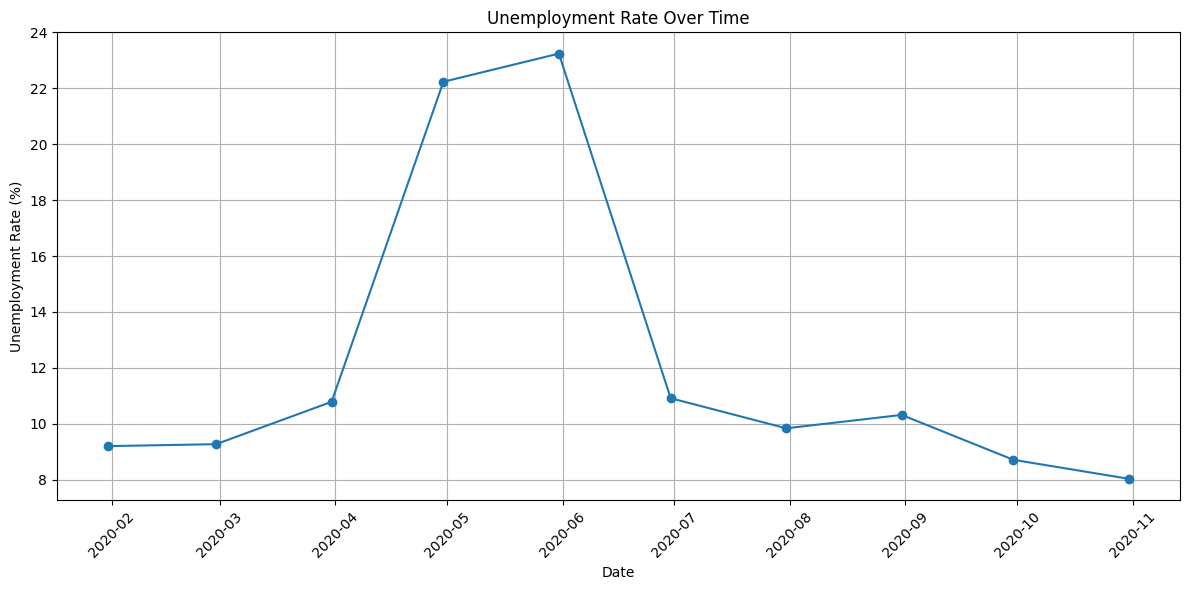

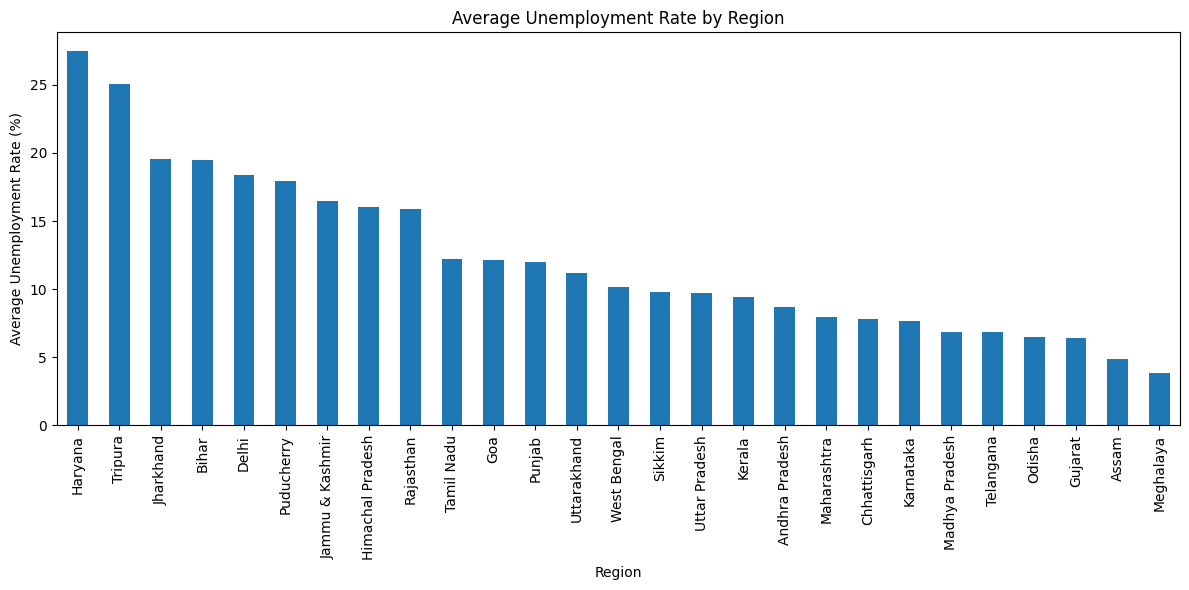

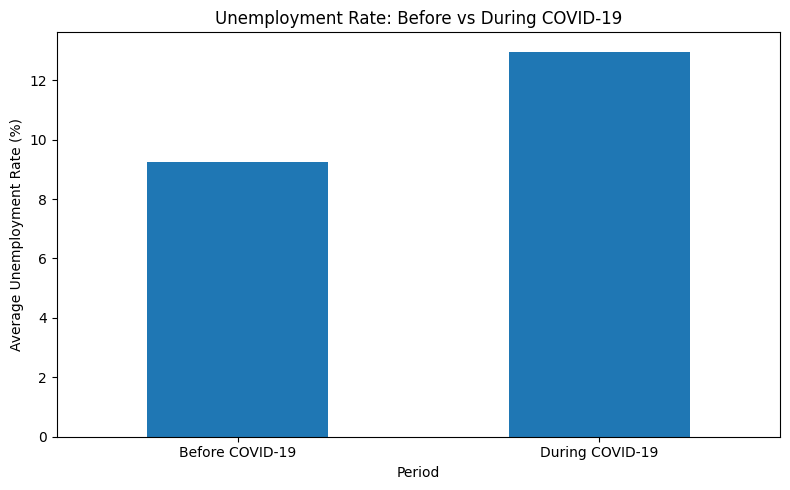

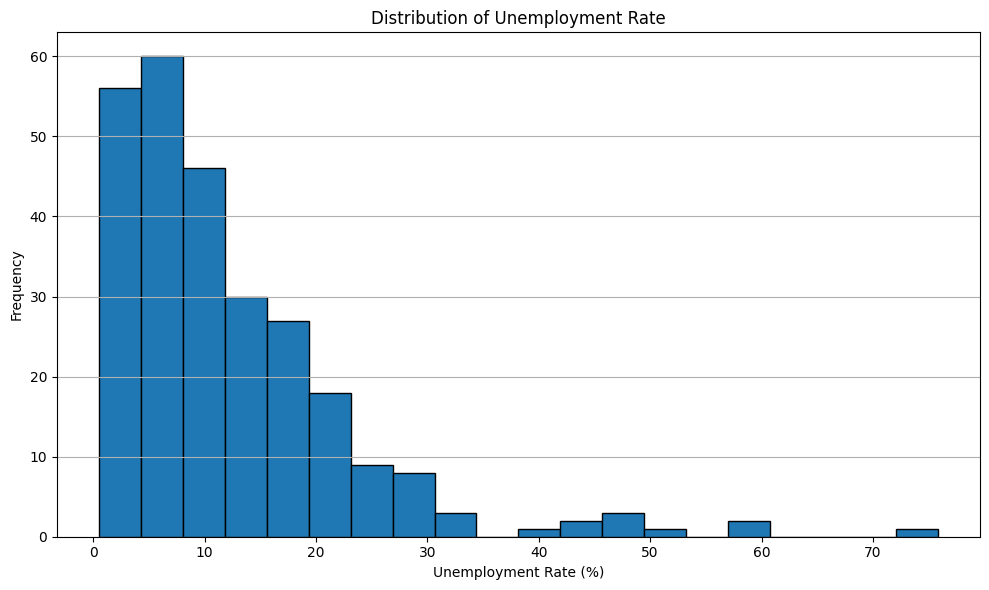

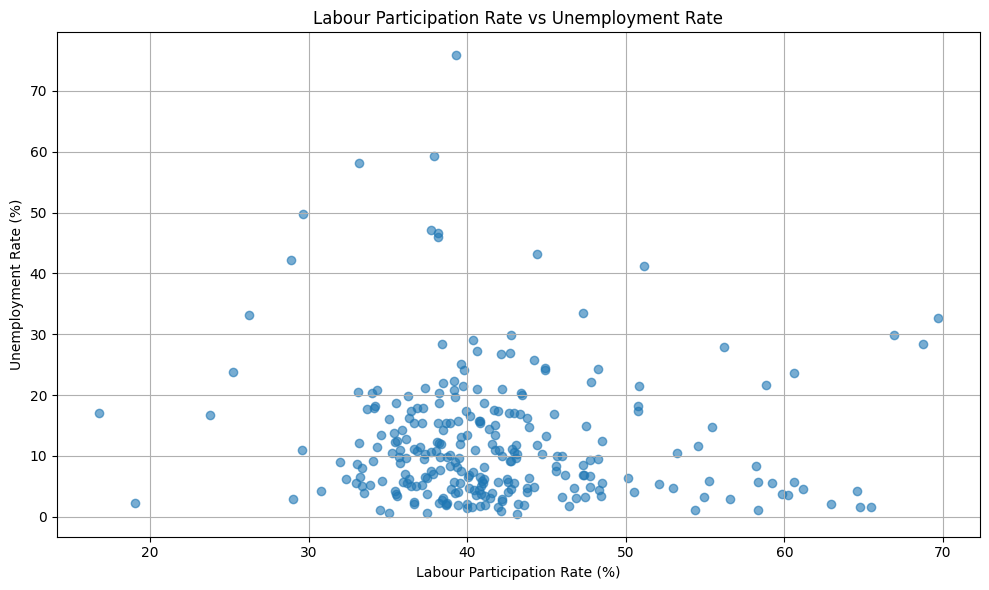

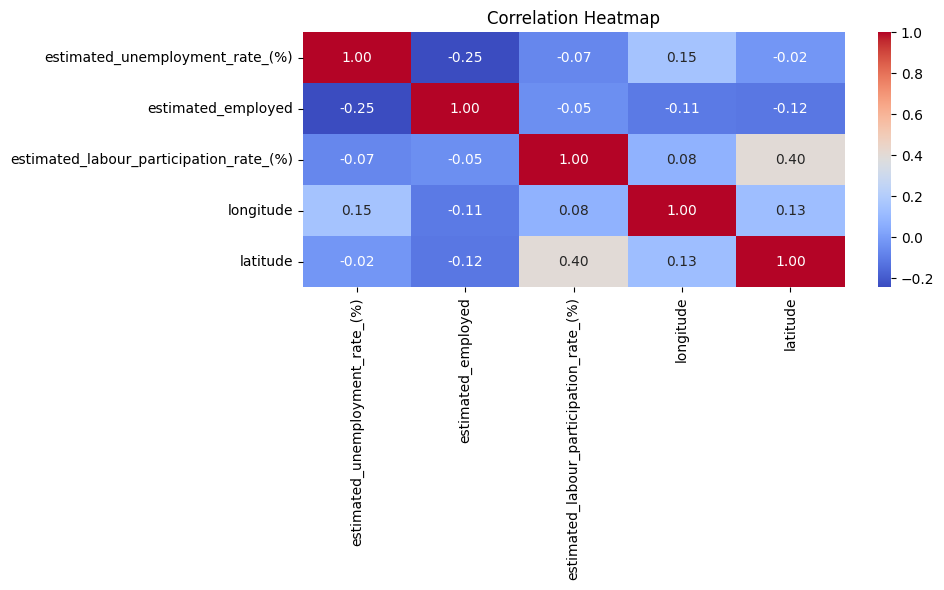


========== CONCLUSION ==========
1. The unemployment analysis shows unemployment trends over time.
2. Regional analysis helps identify regions with higher and lower unemployment.
3. The COVID-19 comparison shows the impact of the pandemic on unemployment.
4. The histogram shows the distribution of unemployment rates.
5. Labour participation can be compared with unemployment using the scatter plot.

Overall, data analysis and visualization help understand unemployment patterns and support better economic decision-making.


In [ ]:
# ============================================
# CODEALPHA TASK 2: UNEMPLOYMENT ANALYSIS
# ============================================

# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile

# ============================================
# 2. Load Dataset
# ============================================

file_path = "/content/Unemployment.CSV.zip"

# Read specific CSV file from ZIP
with zipfile.ZipFile(file_path, 'r') as z:
    # We can choose which file to load. Let's load 'Unemployment_Rate_upto_11_2020.csv'
    # as it represents the typical cleaned dataset for this task.
    csv_filename = "Unemployment_Rate_upto_11_2020.csv"
    with z.open(csv_filename) as f:
        df = pd.read_csv(f, encoding="latin1")

print("Dataset Loaded Successfully!")
print("Shape:", df.shape)

print("\nFirst 5 Rows:")
print(df.head())

print("\nOriginal Column Names:")
print(df.columns.tolist())

# ============================================
# 3. Clean Column Names
# ============================================

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

print("\nCleaned Column Names:")
print(df.columns.tolist())

# ============================================
# 4. Set Column Names
# ============================================

# Common columns in CodeAlpha unemployment dataset

date_col = "date"
region_col = "region"
unemployment_col = "estimated_unemployment_rate_(%)"
labour_col = "estimated_labour_participation_rate_(%)"

print("\nSelected Columns:")
print("Date:", date_col)
print("Region:", region_col)
print("Unemployment:", unemployment_col)
print("Labour:", labour_col)

# ============================================
# 5. Check Columns
# ============================================

if unemployment_col not in df.columns:
    print("\nERROR: Unemployment column not found!")
    print("Available columns:")
    print(df.columns.tolist())

else:

    # ============================================
    # 6. Convert Date
    # ============================================

    df[date_col] = pd.to_datetime(
        df[date_col],
        errors="coerce"
    )

    # ============================================
    # 7. Convert Numeric Columns
    # ============================================

    df[unemployment_col] = pd.to_numeric(
        df[unemployment_col],
        errors="coerce"
    )

    if labour_col in df.columns:
        df[labour_col] = pd.to_numeric(
            df[labour_col],
            errors="coerce"
        )

    # ============================================
    # 8. Remove Missing Values
    # ============================================

    df = df.dropna(subset=[unemployment_col])

    print("\nMissing Values:")
    print(df.isnull().sum())

    # ============================================
    # 9. Basic Statistics
    # ============================================

    print("\n========== BASIC STATISTICS ==========")

    print(
        "Average Unemployment Rate:",
        round(df[unemployment_col].mean(), 2),
        "%"
    )

    print(
        "Maximum Unemployment Rate:",
        round(df[unemployment_col].max(), 2),
        "%"
    )

    print(
        "Minimum Unemployment Rate:",
        round(df[unemployment_col].min(), 2),
        "%"
    )

    # ============================================
    # GRAPH 1: Unemployment Rate Over Time
    # ============================================

    monthly = df.groupby(date_col)[
        unemployment_col
    ].mean()

    plt.figure(figsize=(12, 6))

    plt.plot(
        monthly.index,
        monthly.values,
        marker="o"
    )

    plt.title("Unemployment Rate Over Time")
    plt.xlabel("Date")
    plt.ylabel("Unemployment Rate (%)")
    plt.xticks(rotation=45)
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    # ============================================
    # GRAPH 2: Average Unemployment by Region
    # ============================================

    if region_col in df.columns:

        region_data = df.groupby(
            region_col
        )[unemployment_col].mean()

        region_data = region_data.sort_values(
            ascending=False
        )

        plt.figure(figsize=(12, 6))

        region_data.plot(kind="bar")

        plt.title(
            "Average Unemployment Rate by Region"
        )

        plt.xlabel("Region")
        plt.ylabel(
            "Average Unemployment Rate (%)"
        )

        plt.xticks(rotation=90)

        plt.tight_layout()
        plt.show()

    # ============================================
    # GRAPH 3: Before vs During COVID-19
    # ============================================

    before_covid = df[
        df[date_col] < "2020-03-01"
    ][unemployment_col].mean()

    during_covid = df[
        (df[date_col] >= "2020-03-01") &
        (df[date_col] <= "2021-12-31")
    ][unemployment_col].mean()

    covid_data = pd.Series({
        "Before COVID-19": before_covid,
        "During COVID-19": during_covid
    })

    plt.figure(figsize=(8, 5))

    covid_data.plot(kind="bar")

    plt.title(
        "Unemployment Rate: Before vs During COVID-19"
    )

    plt.xlabel("Period")
    plt.ylabel(
        "Average Unemployment Rate (%)"
    )

    plt.xticks(rotation=0)

    plt.tight_layout()
    plt.show()

    # ============================================
    # GRAPH 4: Distribution of Unemployment Rate
    # ============================================

    plt.figure(figsize=(10, 6))

    plt.hist(
        df[unemployment_col],
        bins=20,
        edgecolor="black"
    )

    plt.title(
        "Distribution of Unemployment Rate"
    )

    plt.xlabel("Unemployment Rate (%)")
    plt.ylabel("Frequency")

    plt.grid(axis="y")

    plt.tight_layout()
    plt.show()

    # ============================================
    # GRAPH 5: Labour Participation vs Unemployment
    # ============================================

    if labour_col in df.columns:

        plt.figure(figsize=(10, 6))

        plt.scatter(
            df[labour_col],
            df[unemployment_col],
            alpha=0.6
        )

        plt.title(
            "Labour Participation Rate vs Unemployment Rate"
        )

        plt.xlabel(
            "Labour Participation Rate (%)"
        )

        plt.ylabel(
            "Unemployment Rate (%)"
        )

        plt.grid(True)

        plt.tight_layout()
        plt.show()

    # ============================================
    # GRAPH 6: Correlation Heatmap
    # ============================================

    numeric_df = df.select_dtypes(
        include=np.number
    )

    plt.figure(figsize=(10, 6))

    sns.heatmap(
        numeric_df.corr(),
        annot=True,
        cmap="coolwarm",
        fmt=".2f"
    )

    plt.title("Correlation Heatmap")

    plt.tight_layout()
    plt.show()

    # ============================================
    # 10. Final Conclusion
    # ============================================

    print("\n========== CONCLUSION ==========")

    print(
        "1. The unemployment analysis shows unemployment "
        "trends over time."
    )

    print(
        "2. Regional analysis helps identify regions "
        "with higher and lower unemployment."
    )

    print(
        "3. The COVID-19 comparison shows the impact "
        "of the pandemic on unemployment."
    )

    print(
        "4. The histogram shows the distribution of "
        "unemployment rates."
    )

    print(
        "5. Labour participation can be compared with "
        "unemployment using the scatter plot."
    )

    print(
        "\nOverall, data analysis and visualization "
        "help understand unemployment patterns and "
        "support better economic decision-making."
    )